In [ ]:

import os
import h5py
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


# ============================================================
# Geometry helpers
# ============================================================

def get_ranges(trX, trY, screen_w, screen_h, img_w, img_h):
    """
    Convert fixation position into source/destination index ranges.

    Returns
    -------
    xdst, ydst : destination indices on screen
    xsrc, ysrc : source indices on image
    """
    ymin = (screen_h / 2) - trY + 1
    ymax = img_h + (screen_h / 2) - trY
    xmin = (screen_w / 2) - trX + 1
    xmax = img_w + (screen_w / 2) - trX

    ymin = max(1, ymin)
    xmin = max(1, xmin)
    ymax = min(screen_h, ymax)
    xmax = min(screen_w, xmax)

    rx = np.arange(1, screen_w + 1)
    ry = np.arange(1, screen_h + 1)

    rxuse = (rx >= xmin) & (rx <= xmax)
    ryuse = (ry >= ymin) & (ry <= ymax)

    xsrc = trX - (screen_w / 2) + rx[rxuse]
    ysrc = trY - (screen_h / 2) + ry[ryuse]

    xsrc = np.round(xsrc).astype(int) - 1
    ysrc = np.round(ysrc).astype(int) - 1

    xdst = np.where(rxuse)[0]
    ydst = np.where(ryuse)[0]

    return xdst, ydst, xsrc, ysrc


# ============================================================
# Movie reconstruction
# ============================================================

def return_fix_movie(screen_size, image_stack, fixations):
    """
    Reconstruct movie from image stack and fixation table.

    Parameters
    ----------
    screen_size : tuple
        (screen_h, screen_w)
    image_stack : ndarray
        Shape (n_images, img_h, img_w)
    fixations : ndarray
        Shape (n_frames, 3), columns [image_id, x, y]

    Returns
    -------
    movie : ndarray
        Shape (screen_h, screen_w, n_frames)
    """
    screen_h, screen_w = screen_size
    n_images, img_h, img_w = image_stack.shape
    n_frames = fixations.shape[0]

    movie = np.zeros((screen_h, screen_w, n_frames), dtype=np.float32)

    for i in range(n_frames):
        img_idx = int(fixations[i, 0]) - 1  # MATLAB -> Python indexing
        trX = float(fixations[i, 1])
        trY = float(fixations[i, 2])

        if img_idx < 0 or img_idx >= n_images:
            continue

        xdst, ydst, xsrc, ysrc = get_ranges(
            trX, trY, screen_w, screen_h, img_w, img_h
        )

        patch = image_stack[img_idx][np.ix_(ysrc, xsrc)]
        movie[np.ix_(ydst, xdst, [i])] = patch[:, :, None]

    return movie


# ============================================================
# Trace processing
# ============================================================

def center_trace(fixations):
    """
    Center x,y trace at the starting point.

    Parameters
    ----------
    fixations : ndarray
        Shape (T, 3), columns [image_id, x, y]

    Returns
    -------
    pos : ndarray
        Shape (T, 2), centered position trace
    """
    pos = fixations[:, 1:3].astype(np.float32)
    pos -= pos[0]
    return pos


def compute_velocity(pos, fps=75):
    """
    Compute velocity from centered position trace.

    Parameters
    ----------
    pos : ndarray
        Shape (T, 2)
    fps : float

    Returns
    -------
    vel : ndarray
        Shape (T, 2)
    """
    dt = 1.0 / fps
    vel = np.zeros_like(pos, dtype=np.float32)
    vel[1:] = np.diff(pos, axis=0) / dt
    return vel


def compute_speed(vel):
    """
    Compute speed from velocity.

    Parameters
    ----------
    vel : ndarray
        Shape (T, 2)

    Returns
    -------
    speed : ndarray
        Shape (T,)
    """
    return np.linalg.norm(vel, axis=1)


def split_into_segments(fixations, frames_per_image=75):
    """
    Split fixation array into 1-second chunks.

    Parameters
    ----------
    fixations : ndarray
        Shape (n_frames, 3)
    frames_per_image : int

    Returns
    -------
    segments : list of ndarray
    """
    n_segments = fixations.shape[0] // frames_per_image
    return [
        fixations[i * frames_per_image:(i + 1) * frames_per_image]
        for i in range(n_segments)
    ]


# ============================================================
# Saving movies
# ============================================================

def save_movie(movie, out_path, fps=75):
    """
    Save movie to mp4 or gif.

    Parameters
    ----------
    movie : ndarray
        Shape (H, W, T)
    out_path : str
    fps : int
    """
    frames = np.moveaxis(movie, 2, 0)  # (T, H, W)

    if frames.dtype != np.uint8:
        frames = frames.astype(np.float32)
        fmin, fmax = frames.min(), frames.max()
        if fmax > fmin:
            frames = 255 * (frames - fmin) / (fmax - fmin)
        else:
            frames = np.zeros_like(frames)
        frames = frames.astype(np.uint8)

    ext = os.path.splitext(out_path)[1].lower()

    if ext == ".gif":
        iio.imwrite(out_path, frames, duration=1 / fps, loop=0)
    else:
        iio.imwrite(out_path, frames, fps=fps)


# ============================================================
# Plotting
# ============================================================

def plot_centered_trace(pos, title="Centered trace", out_path=None, show=True):
    """
    Plot centered x-y trace.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(pos[:, 0], pos[:, 1], lw=1.5)
    ax.scatter(pos[0, 0], pos[0, 1], s=60, marker='o', label='start')
    ax.scatter(pos[-1, 0], pos[-1, 1], s=60, marker='x', label='end')

    ax.set_xlabel("x - x(0)")
    ax.set_ylabel("y - y(0)")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend()

    lim = max(np.max(np.abs(pos[:, 0])), np.max(np.abs(pos[:, 1])), 1.0) * 1.05
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    fig.tight_layout()
    if out_path is not None:        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_position_velocity(pos, vel, fps=75, title="Position and velocity", out_path=None, show=True):
    """
    Plot x(t), y(t), vx(t), vy(t), and speed(t).
    """
    T = pos.shape[0]
    t = np.arange(T) / fps
    speed = compute_speed(vel)

    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

    axes[0].plot(t, pos[:, 0], label="x - x(0)")
    axes[0].plot(t, pos[:, 1], label="y - y(0)")
    axes[0].set_ylabel("position")
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(t, vel[:, 0], label="vx")
    axes[1].plot(t, vel[:, 1], label="vy")
    axes[1].set_ylabel("velocity")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(t, speed, label="speed")
    axes[2].set_ylabel("speed")
    axes[2].set_xlabel("time (s)")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# Animated visualization
# ============================================================

def visualize_sample_with_velocity(movie, fixations, fps=75, title="sample", save_path=None):
    """
    Animate movie with centered trajectory, position traces, and velocity traces.

    Parameters
    ----------
    movie : ndarray
        Shape (H, W, T)
    fixations : ndarray
        Shape (T, 3)
    fps : int
    title : str
    save_path : str or None
        If given, save animation to mp4/gif
    """
    pos = center_trace(fixations)
    vel = compute_velocity(pos, fps=fps)

    T = movie.shape[2]
    t = np.arange(T) / fps

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ax_img, ax_trace = axes[0]
    ax_pos, ax_vel = axes[1]
    
    im = ax_img.imshow(movie[:, :, 0], cmap="gray", vmin=0.0, vmax=255.0)
    ax_img.set_title(f"{title} | frame 1/{T}")
    ax_img.axis("off")

    ax_trace.plot(pos[:, 0], pos[:, 1], color="0.7", lw=1)
    trace_point, = ax_trace.plot(pos[0, 0], pos[0, 1], "ro")
    ax_trace.plot(pos[0, 0], pos[0, 1], "go", label="start")
    ax_trace.plot(pos[-1, 0], pos[-1, 1], "bx", label="end")
    ax_trace.set_title("Centered trajectory")
    ax_trace.set_xlabel("x - x(0)")
    ax_trace.set_ylabel("y - y(0)")
    ax_trace.set_aspect("equal")
    ax_trace.grid(True, alpha=0.3)
    ax_trace.legend()

    lim = max(np.max(np.abs(pos[:, 0])), np.max(np.abs(pos[:, 1])), 1) * 1.05
    ax_trace.set_xlim(-lim, lim)
    ax_trace.set_ylim(-lim, lim)

    ax_pos.plot(t, pos[:, 0], label="x - x(0)")
    ax_pos.plot(t, pos[:, 1], label="y - y(0)")
    pos_cursor = ax_pos.axvline(t[0], color="k", linestyle="--", alpha=0.7)
    ax_pos.set_title("Position traces")
    ax_pos.set_xlabel("time (s)")
    ax_pos.set_ylabel("position")
    ax_pos.grid(True, alpha=0.3)
    ax_pos.legend()

    ax_vel.plot(t, vel[:, 0], label="vx")
    ax_vel.plot(t, vel[:, 1], label="vy")
    vel_cursor = ax_vel.axvline(t[0], color="k", linestyle="--", alpha=0.7)
    ax_vel.set_title("Velocity traces")
    ax_vel.set_xlabel("time (s)")
    ax_vel.set_ylabel("velocity")
    ax_vel.grid(True, alpha=0.3)
    ax_vel.legend()

    plt.tight_layout()

    def update(frame):
        im.set_data(movie[:, :, frame])
        ax_img.set_title(f"{title} | frame {frame + 1}/{T}")
        trace_point.set_data([pos[frame, 0]], [pos[frame, 1]])
        pos_cursor.set_xdata([t[frame], t[frame]])
        vel_cursor.set_xdata([t[frame], t[frame]])
        return im, trace_point, pos_cursor, vel_cursor

    anim = FuncAnimation(fig, update, frames=T, interval=1000 / fps, blit=False)

    if save_path is not None:
        anim.save(save_path, fps=fps, dpi=150)

    plt.show()
    return anim


## Load Data

In [ ]:

# -----------------------------
# Params
# -----------------------------
file = 'mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat'
screen_size = (600, 800)   # rows, cols
whichRun = 1               # MATLAB-style indexing
frames_per_image = 75
fps = 75

os.makedirs("saved_movies", exist_ok=True)
os.makedirs("saved_plots", exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
with h5py.File(file, 'r') as f:
    frozen_images = np.array(f['frozenImages']).transpose((0, 2, 1)).astype(np.float32)
    frozen_fixations = np.array(f['frozenfixations']).astype(np.float32)
    running_images = np.array(f['runningImages']).transpose((0, 2, 1)).astype(np.float32)
    running_fixations = np.array(f['runningfixations']).astype(np.float32)

print("frozen_images:", frozen_images.shape)
print("frozen_fixations:", frozen_fixations.shape)
print("running_images:", running_images.shape)
print("running_fixations:", running_fixations.shape)


frozen_images: (25, 1024, 1532)
frozen_fixations: (1875, 3)
running_images: (300, 1024, 1532)
running_fixations: (31, 2625, 3)


In [ ]:
global_min = min(frozen_images.min(), running_images.min())
global_max = max(frozen_images.max(), running_images.max())
scale = global_max - global_min + 1e-8

frozen_images = (frozen_images - global_min) / scale
running_images = (running_images - global_min) / scale
# ### global z score
# global_mean = np.mean([frozen_images.mean(), running_images.mean()])
# global_std = np.sqrt(np.mean([frozen_images.var(), running_images.var()]))
# frozen_images = (frozen_images - global_mean) / global_std
# running_images = (running_images - global_mean) / global_std

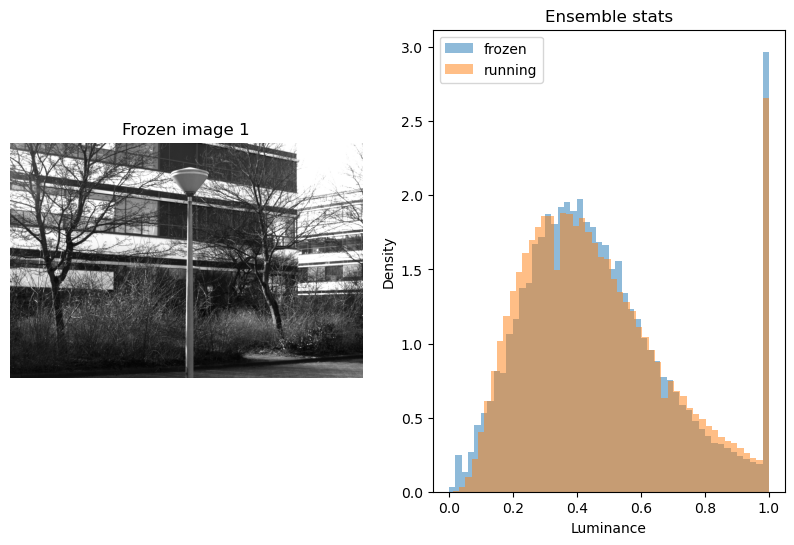

In [81]:

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Show one example image
axes[0].imshow(frozen_images[0], cmap="gray")
#draw 400x400 box in center in red
# rect = plt.Rectangle((), 400, 400, edgecolor='red', facecolor='none', lw=2)
# axes[0].add_patch(rect)
axes[0].set_title("Frozen image 1")
axes[0].axis("off")

axes[1].set_title("Ensemble stats")
axes[1].hist(frozen_images.ravel(), bins=50, density=True, alpha=0.5, label="frozen")
# axes[1].hist(frozen_images[0].ravel(), bins=100, density=True, range=(0,1), alpha=0.5, label="frozen")
axes[1].hist(running_images.ravel(), bins=50, density=True, alpha=0.5, label="running")
# axes[1].hist(running_images[0].ravel(), bins=100, density=True, range=(0,1), alpha=0.5, label="running")

axes[1].set_xlabel("Luminance")
axes[1].set_ylabel("Density")
axes[1].legend()
plt.show()

In [82]:
# -----------------------------
# Split into 1 s segments
# -----------------------------
frozen_segments = split_into_segments(frozen_fixations, frames_per_image=frames_per_image)

run_fix = running_fixations[whichRun - 1]
running_segments = split_into_segments(run_fix, frames_per_image=frames_per_image)

print("num frozen segments:", len(frozen_segments))
print(f"num running segments in run {whichRun}:", len(running_segments))


num frozen segments: 25
num running segments in run 1: 35


In [ ]:
# -----------------------------
# Pick example segments
# -----------------------------
frozen_seg = frozen_segments[0]
running_seg = running_segments[0]

print("Frozen segment image IDs:", np.unique(frozen_seg[:, 0]))
print("Running segment image IDs:", np.unique(running_seg[:, 0]))

# -----------------------------
# Reconstruct movies
# -----------------------------
frozen_movie = return_fix_movie(screen_size, frozen_images, frozen_seg)
running_movie = return_fix_movie(screen_size, running_images, running_seg)

print("frozen_movie:", frozen_movie.shape)
print("running_movie:", running_movie.shape)

# -----------------------------
# Compute traces + velocity
# -----------------------------
frozen_pos = center_trace(frozen_seg)
frozen_vel = compute_velocity(frozen_pos, fps=fps)

running_pos = center_trace(running_seg)
running_vel = compute_velocity(running_pos, fps=fps)


Frozen segment image IDs: [1.]
Running segment image IDs: [3.]
frozen_movie: (600, 800, 75)
running_movie: (600, 800, 75)


In [84]:
## Crop movies to 400x400 around center
def center_crop_movie(movie, crop_hw=(400, 400)):
    H, W, T = movie.shape
    crop_h, crop_w = crop_hw
    y0 = (H - crop_h) // 2
    x0 = (W - crop_w) // 2
    return movie[y0:y0+crop_h, x0:x0+crop_w, :]

frozen_movie = center_crop_movie(frozen_movie, crop_hw=(400, 400))
running_movie = center_crop_movie(running_movie, crop_hw=(400, 400))

In [85]:
def add_gray_padding(movie, n_gray_frames=15, gray_value=0.5, prepend=True, append=False):
    """
    movie: (H, W, T)
    returns: (H, W, T_new)
    """
    H, W, _ = movie.shape
    gray_block = np.full((H, W, n_gray_frames), gray_value, dtype=movie.dtype)

    parts = []
    if prepend:
        parts.append(gray_block)
    parts.append(movie)
    if append:
        parts.append(gray_block)

    return np.concatenate(parts, axis=2) 

def pad_position_trace(pos, n_gray_frames=15):
    """
    pos: (T, 2)
    repeats first position during gray prelude
    """
    pre = np.repeat(pos[:1], n_gray_frames, axis=0)
    return np.concatenate([pre, pos], axis=0)

def pad_velocity_trace(vel, n_gray_frames=15):
    """
    vel: (T, 2)
    """
    pre = np.zeros((n_gray_frames, vel.shape[1]), dtype=vel.dtype)
    return np.concatenate([pre, vel], axis=0)

def pad_fixations_pre(fixations, n_gray_frames=15):
    """
    fixations: (T, 3) with columns [image_id, x, y]
    returns: (T + n_gray_frames, 3)
    """
    pre = np.repeat(fixations[:1], n_gray_frames, axis=0)
    return np.concatenate([pre, fixations], axis=0)

In [86]:
gray_frames = int(round(0.2 * fps))  # 15

frozen_movie = add_gray_padding(frozen_movie, n_gray_frames=gray_frames, gray_value=0.5, prepend=True, append=False)
running_movie = add_gray_padding(running_movie, n_gray_frames=gray_frames, gray_value=0.5, prepend=True, append=False)
frozen_pos = pad_position_trace(frozen_pos, gray_frames)
running_pos = pad_position_trace(running_pos, gray_frames)

frozen_vel = pad_velocity_trace(frozen_vel, gray_frames)
running_vel = pad_velocity_trace(running_vel, gray_frames)

frozen_seg  = pad_fixations_pre(frozen_seg, n_gray_frames=15)
running_seg = pad_fixations_pre(running_seg, n_gray_frames=15)

print("frozen_movie with gray:", frozen_movie.shape)
print("running_movie with gray:", running_movie.shape)

frozen_movie with gray: (400, 400, 90)
running_movie with gray: (400, 400, 90)


In [ ]:
frozen_movie = np.clip(frozen_movie * 255.0, 0, 255).astype(np.uint8)
running_movie = np.clip(running_movie * 255.0, 0, 255).astype(np.uint8)


## Downsample to 

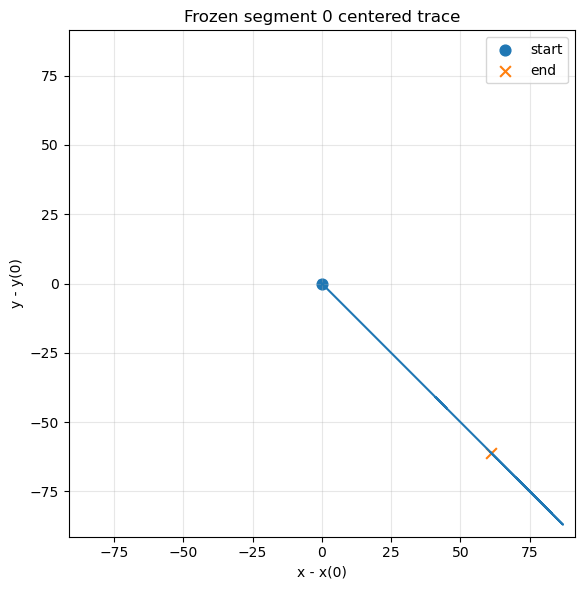

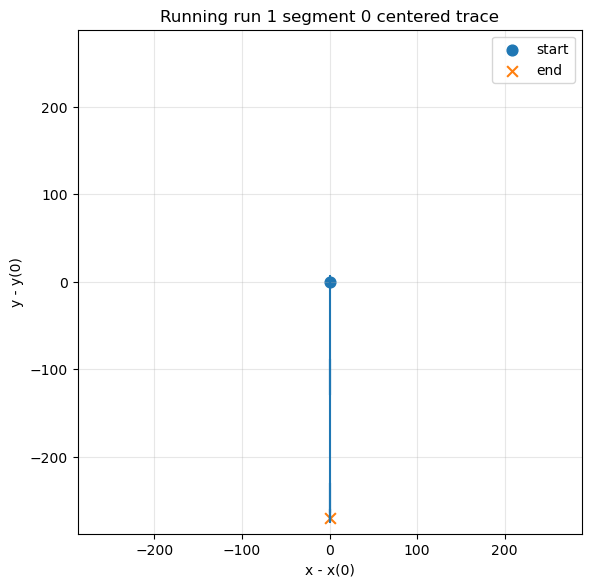

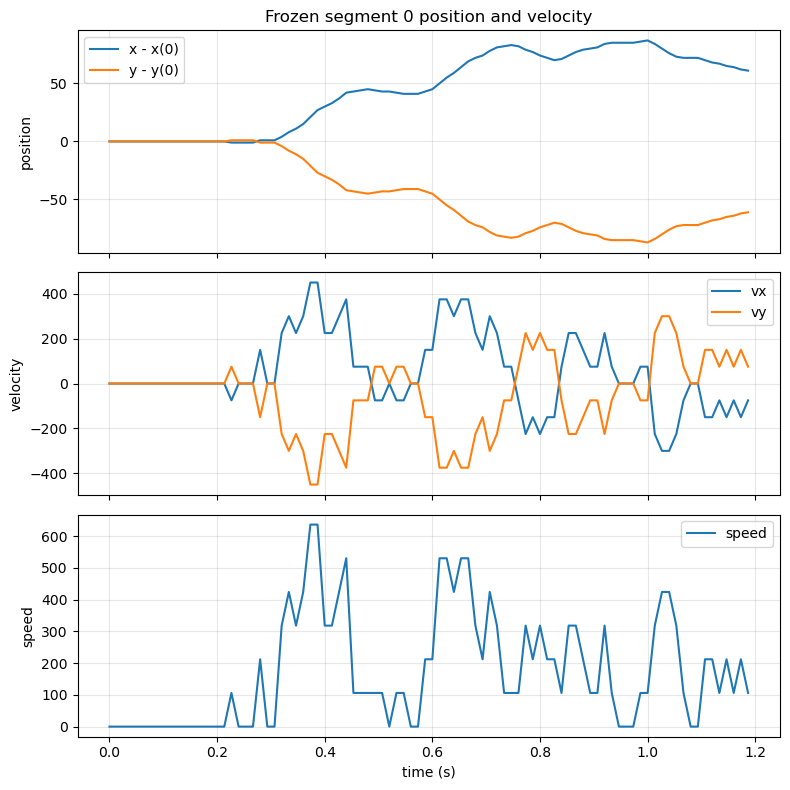

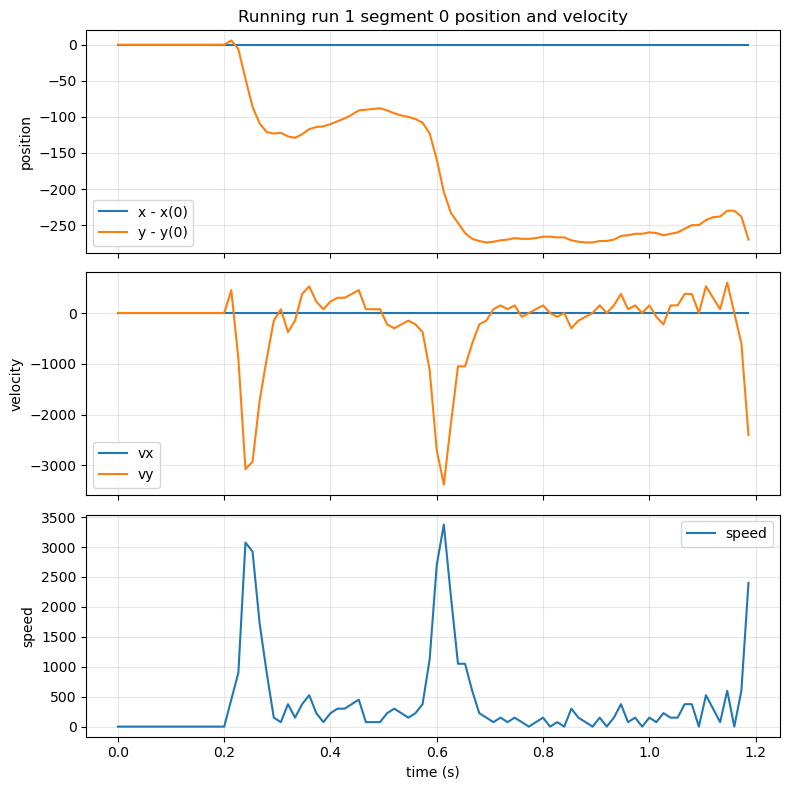

MovieWriter ffmpeg unavailable; using Pillow instead.


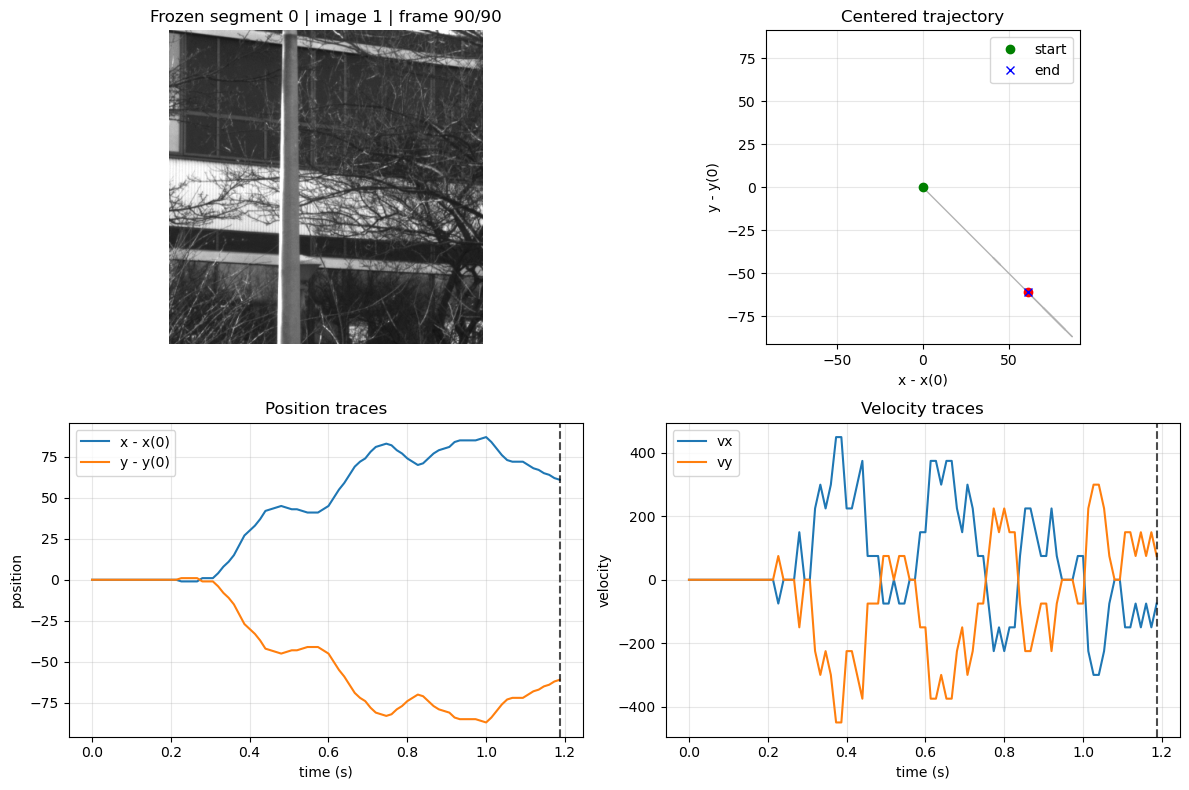

MovieWriter ffmpeg unavailable; using Pillow instead.


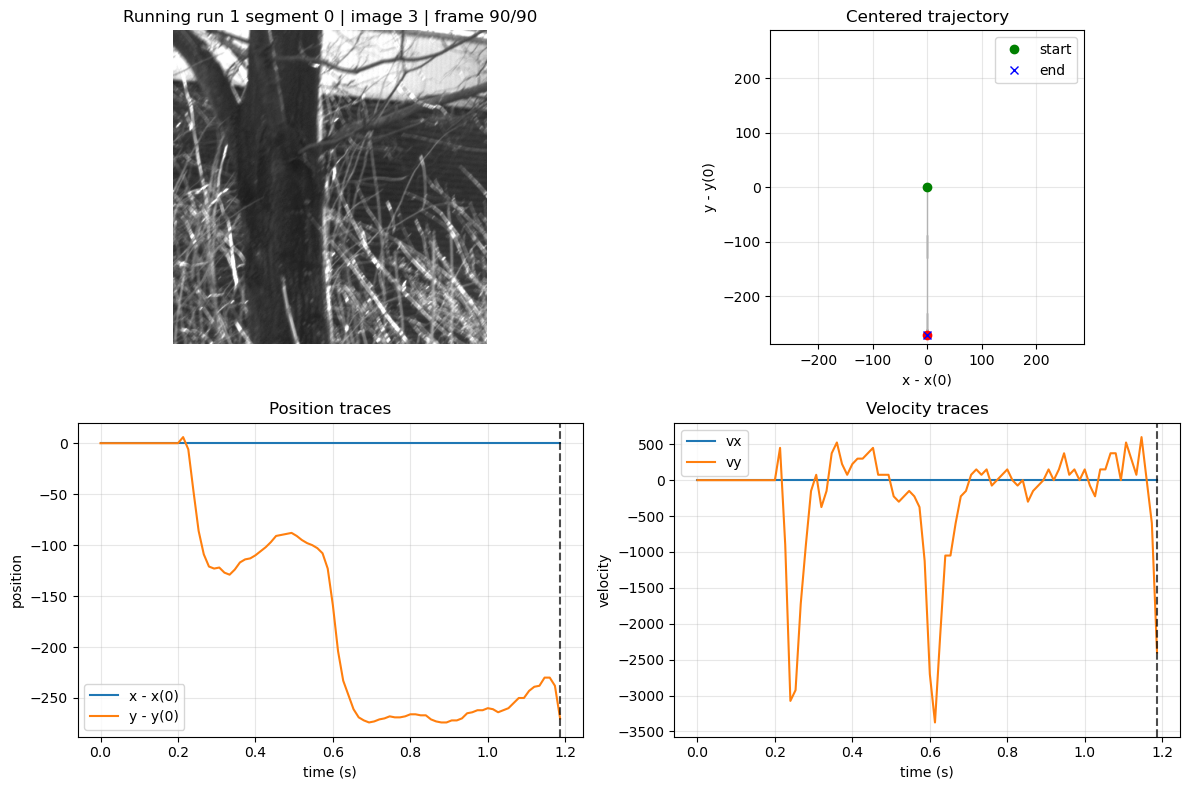

Saved movies to saved_movies/
Saved plots to saved_plots/


In [87]:
# -----------------------------
# Save movies
# -----------------------------
save_movie(frozen_movie, "saved_movies/frozen_segment0.mp4", fps=fps)
save_movie(running_movie, f"saved_movies/running_run{whichRun}_segment0.mp4", fps=fps)

# -----------------------------
# Save trace plots
# -----------------------------
plot_centered_trace(
frozen_pos,
title="Frozen segment 0 centered trace",
out_path="saved_plots/frozen_segment0_centered_trace.png",
show=True
)

plot_centered_trace(
running_pos,
title=f"Running run {whichRun} segment 0 centered trace",
out_path=f"saved_plots/running_run{whichRun}_segment0_centered_trace.png",
show=True
)

plot_position_velocity(
frozen_pos,
frozen_vel,
fps=fps,
title="Frozen segment 0 position and velocity",
out_path="saved_plots/frozen_segment0_pos_vel.png",
show=True
)

plot_position_velocity(
running_pos,
running_vel,
fps=fps,
title=f"Running run {whichRun} segment 0 position and velocity",
out_path=f"saved_plots/running_run{whichRun}_segment0_pos_vel.png",
show=True
)

# -----------------------------
# Animated visualization
# -----------------------------
visualize_sample_with_velocity(
frozen_movie,
frozen_seg,
fps=fps,
title=f"Frozen segment 0 | image {int(frozen_seg[0, 0])}",
save_path="saved_movies/frozen_segment0_annotated.gif"
)

visualize_sample_with_velocity(
running_movie,
running_seg,
fps=fps,
title=f"Running run {whichRun} segment 0 | image {int(running_seg[0, 0])}",
save_path=f"saved_movies/running_run{whichRun}_segment0_annotated.gif"
)

print("Saved movies to saved_movies/")
print("Saved plots to saved_plots/")